# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.


### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.

### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.


В работе реализуется модель коллаборативной фильтрации на основе нейронной сети (Neural Collaborative Filtering).  
Используются реальные пользовательские оценки книг и обучаем модель предсказывать рейтинг.

Работа включает:
- загрузку и анализ данных
- предобработку
- построение нейросетевой модели
- обучение
- оценку качества (RMSE, MAE)
- визуализацию обучения
- генерацию персональных рекомендаций

Данный подход широко используется в современных рекомендательных системах (Amazon, Netflix, Goodreads).


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')


## Загрузка данных

Загружаем:
- books_of_the_decade.csv — информация о книгах
- user_reviews_dataset.csv — пользовательские оценки


In [2]:

books = pd.read_csv("books_of_the_decade.csv")
reviews = pd.read_csv("user_reviews_dataset.csv")

books.head()


,Index,Book Name,Author,Rating,Number of Votes,Score
0,1,The Invisible Life of Addie LaRue,Victoria Schwab,4.18,"1,184,531",62443
1,2,The House in the Cerulean Sea (Cerulean Chroni...,T.J. Klune,4.40,"718,243",47323
2,3,Project Hail Mary,Andy Weir,4.51,"657,869",45972
3,4,The Midnight Library,Matt Haig,3.99,"1,967,348",42746
4,5,I'm Glad My Mom Died,Jennette McCurdy,4.46,"1,151,831",37509



## Предобработка данных

Удаляем запятые в количестве голосов и приводим к числовому формату.


In [3]:
# Оставляем только цифры
books["Number of Votes"] = (
    books["Number of Votes"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

# Преобразуем в число
books["Number of Votes"] = pd.to_numeric(books["Number of Votes"], errors="coerce")

books.head()


,Index,Book Name,Author,Rating,Number of Votes,Score
0,1,The Invisible Life of Addie LaRue,Victoria Schwab,4.18,1184531,62443
1,2,The House in the Cerulean Sea (Cerulean Chroni...,T.J. Klune,4.40,718243,47323
2,3,Project Hail Mary,Andy Weir,4.51,657869,45972
3,4,The Midnight Library,Matt Haig,3.99,1967348,42746
4,5,I'm Glad My Mom Died,Jennette McCurdy,4.46,1151831,37509



## Кодирование пользователей и книг

Для корректной работы embedding-слоев индексы должны начинаться с 0.


In [4]:

user_encoder = {id:i for i, id in enumerate(reviews["userId"].unique())}
reviews["user_id"] = reviews["userId"].map(user_encoder)

book_encoder = {id:i for i, id in enumerate(reviews["bookIndex"].unique())}
reviews["item_id"] = reviews["bookIndex"].map(book_encoder)

num_users = len(user_encoder)
num_items = len(book_encoder)

num_users, num_items


(79957, 2327)


## Создание Dataset и DataLoader

Формируем PyTorch Dataset для пакетного обучения.


In [5]:

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_id"].values, dtype=torch.long)
        self.items = torch.tensor(df["item_id"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["score"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_df, test_df = train_test_split(reviews, test_size=0.2, random_state=42)

train_loader = DataLoader(RatingsDataset(train_df), batch_size=256, shuffle=True)
test_loader = DataLoader(RatingsDataset(test_df), batch_size=256)



## Архитектура модели

Используется embedding-представление пользователей и книг.
Далее признаки объединяются и передаются в полносвязную нейронную сеть.


In [6]:

class RecommenderNN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.fc = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=1)
        return self.fc(x).squeeze()

model = RecommenderNN(num_users, num_items).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)



## Обучение модели

Сохраняем значения функции потерь для последующей визуализации.


In [7]:

losses = []

for epoch in range(10):
    model.train()
    total_loss = 0

    for users, items, ratings in train_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)

        optimizer.zero_grad()
        preds = model(users, items)
        loss = criterion(preds, ratings)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 2.1062
Epoch 2, Loss: 1.9617
Epoch 3, Loss: 1.7883
Epoch 4, Loss: 1.5297
Epoch 5, Loss: 1.1916
Epoch 6, Loss: 0.8570
Epoch 7, Loss: 0.5904
Epoch 8, Loss: 0.3993
Epoch 9, Loss: 0.2767
Epoch 10, Loss: 0.2029



## Визуализация обучения

График показывает динамику уменьшения ошибки во время обучения.
Снижение loss свидетельствует о том, что модель обучается корректно.


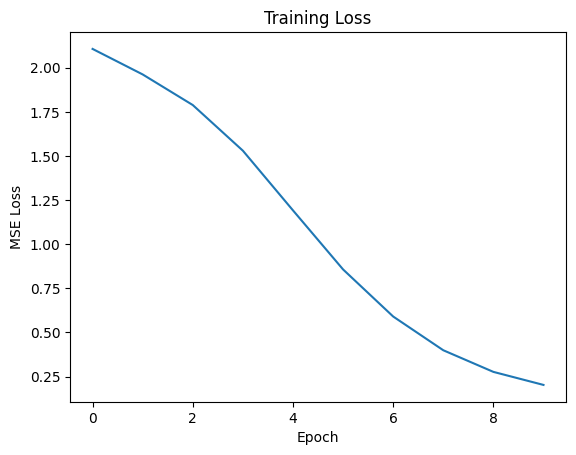

In [8]:

plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()



## Оценка качества модели

Используем метрики:
- RMSE — корень из средней квадратичной ошибки
- MAE — средняя абсолютная ошибка

Чем ниже значения — тем лучше модель предсказывает оценки.


In [9]:

model.eval()
preds_list = []
true_list = []

with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items = users.to(device), items.to(device)
        preds = model(users, items).cpu().numpy()
        preds_list.extend(preds)
        true_list.extend(ratings.numpy())

rmse = math.sqrt(mean_squared_error(true_list, preds_list))
mae = mean_absolute_error(true_list, preds_list)

print("Test RMSE:", rmse)
print("Test MAE:", mae)


Test RMSE: 1.830919671009178
Test MAE: 1.502394595179955
